# 01_eda.ipynb
特徴量エンジニアリングを実装に当たっての示唆を得るためのノートブックファイル.実験的な内容を伴う.

## 準備

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_fontja  # noqa: F401

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.clean import refine_data
from src.preprocessing.feature_engineering import engineer_features
from src.preprocessing.clean import preprocess_data

pd.set_option("display.max_columns", None)

In [2]:
# rawデータのロード（国土交通省CSVはCP932/Shift_JISで配布されている）
df_raw = pd.read_csv('../data/raw/Tokyo_20251_20254.csv', encoding='cp932')
display(df_raw.head())

,種類,価格情報区分,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,間取り,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,取引時期,改装,取引の事情等
0,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,小伝馬町,2,59000000,１ＬＤＫ,45,2014年,ＲＣ,NaN,NaN,商業,NaN,NaN,2025年第1四半期,NaN,NaN
1,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,岩本町,4,120000000,２ＬＤＫ,55,2023年,ＲＣ,NaN,NaN,商業,NaN,NaN,2025年第1四半期,NaN,NaN
2,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,岩本町,NaN,38000000,１ＤＫ,40,2007年,ＲＣ,NaN,NaN,商業,NaN,NaN,2025年第1四半期,NaN,NaN
3,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,岩本町,3,65000000,２ＬＤＫ,45,2016年,ＲＣ,NaN,NaN,NaN,NaN,NaN,2025年第1四半期,NaN,NaN
4,中古マンション等,成約価格情報,13101,東京都,千代田区,九段北,市ケ谷,3,45000000,１Ｋ,35,2005年,鉄骨造,NaN,NaN,商業,NaN,NaN,2025年第1四半期,NaN,NaN


## 分析

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 39666 entries, 0 to 39665
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   種類         39666 non-null  str    
 1   価格情報区分     39666 non-null  str    
 2   市区町村コード    39666 non-null  int64  
 3   都道府県名      39666 non-null  str    
 4   市区町村名      39666 non-null  str    
 5   地区名        39666 non-null  str    
 6   最寄駅：名称     39629 non-null  str    
 7   最寄駅：距離（分）  38956 non-null  str    
 8   取引価格（総額）   39666 non-null  int64  
 9   間取り        38637 non-null  str    
 10  面積（㎡）      39666 non-null  int64  
 11  建築年        39346 non-null  str    
 12  建物の構造      39138 non-null  str    
 13  用途         10950 non-null  str    
 14  今後の利用目的    12459 non-null  str    
 15  都市計画       39265 non-null  str    
 16  建ぺい率（％）    12903 non-null  float64
 17  容積率（％）     12903 non-null  float64
 18  取引時期       39666 non-null  str    
 19  改装         11809 non-null  str    
 20  取引の事情等     46 non

In [4]:
display(df_raw.isna().sum())

種類               0
価格情報区分           0
市区町村コード          0
都道府県名            0
市区町村名            0
地区名              0
最寄駅：名称          37
最寄駅：距離（分）      710
取引価格（総額）         0
間取り           1029
面積（㎡）            0
建築年            320
建物の構造          528
用途           28716
今後の利用目的      27207
都市計画           401
建ぺい率（％）      26763
容積率（％）       26763
取引時期             0
改装           27857
取引の事情等       39620
dtype: int64

In [5]:
# 欠損率と、距離列との重なりを見る
display(df_raw[['最寄駅：名称', '最寄駅：距離（分）', '市区町村名']].isna().sum())
display(df_raw[df_raw['最寄駅：名称'].isna()]['市区町村名'].value_counts().head(10))

最寄駅：名称        37
最寄駅：距離（分）    710
市区町村名          0
dtype: int64

市区町村名
港区      5
大田区     5
台東区     3
杉並区     3
新宿区     2
目黒区     2
世田谷区    2
練馬区     2
日野市     2
中央区     1
Name: count, dtype: int64

In [6]:
df_raw["用途"].value_counts()

用途
住宅        10822
事務所          58
店舗           40
その他          22
事務所、店舗        3
駐車場           2
住宅、その他        2
倉庫            1
Name: count, dtype: int64

In [7]:
df_raw["今後の利用目的"].value_counts()

今後の利用目的
住宅     11240
その他      982
事務所      186
店舗        51
Name: count, dtype: int64

In [8]:
# 両列がともに記入されている行で、対応関係を見る
both_filled = df_raw.dropna(subset=['用途', '今後の利用目的'])

# クロス集計
crosstab = pd.crosstab(
    both_filled['用途'],
    both_filled['今後の利用目的'],
    margins=True,
    normalize='index',  # 用途ごとの割合
)
print(crosstab)

# 用途='住宅' のとき、今後の利用目的の内訳
print(both_filled[both_filled['用途'] == '住宅']['今後の利用目的'].value_counts(normalize=True))

今後の利用目的       その他       事務所        住宅        店舗
用途                                             
その他      1.000000  0.000000  0.000000  0.000000
事務所      0.087719  0.771930  0.122807  0.017544
事務所、店舗   0.000000  0.000000  0.000000  1.000000
住宅       0.075106  0.009545  0.914674  0.000675
住宅、その他   0.000000  0.000000  1.000000  0.000000
倉庫       0.000000  1.000000  0.000000  0.000000
店舗       0.102564  0.000000  0.025641  0.871795
駐車場      1.000000  0.000000  0.000000  0.000000
All      0.077348  0.013717  0.904649  0.004287
今後の利用目的
住宅     0.914674
その他    0.075106
事務所    0.009545
店舗     0.000675
Name: proportion, dtype: float64


In [9]:
display(df_raw["都市計画"].value_counts())

都市計画
商業      11850
準工業      7199
１中住専     5207
近隣商業     4649
１種住居     4112
１低住専     1843
２種住居     1606
工業       1133
２中住専      910
準住居       620
２低住専      131
工業専用        5
Name: count, dtype: int64

In [10]:
display(df_raw["改装"].value_counts())

改装
未改装     7310
改装済み    4499
Name: count, dtype: int64

In [11]:
df_raw["建築年"].value_counts()

建築年
2005年    1229
2019年    1219
2003年    1160
2004年    1154
2006年    1103
         ... 
1956年       1
2027年       1
1958年       1
1954年       1
戦前          1
Name: count, Length: 73, dtype: int64

In [12]:
df_raw = refine_data(df_raw)
display(df_raw.isna().sum())
display(df_raw.head())

種類           0
価格情報区分       0
市区町村コード      0
都道府県名        0
市区町村名        0
地区名          0
最寄駅：名称       0
最寄駅：距離（分）    0
取引価格（総額）     0
間取り          0
面積（㎡）        0
建築年          0
建物の構造        0
用途           0
今後の利用目的      0
都市計画         0
建ぺい率（％）      0
容積率（％）       0
取引時期         0
改装           0
築年数          0
dtype: int64

,種類,価格情報区分,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,間取り,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,取引時期,改装,築年数
0,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,小伝馬町,2.0,59000000,１ＬＤＫ,45,2014.0,ＲＣ,住宅,住宅,商業,80.0,600.0,2025年第1四半期,Unknown,12.0
1,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,岩本町,4.0,120000000,２ＬＤＫ,55,2023.0,ＲＣ,住宅,住宅,商業,80.0,600.0,2025年第1四半期,Unknown,3.0
2,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,岩本町,5.0,38000000,１ＤＫ,40,2007.0,ＲＣ,住宅,住宅,商業,80.0,600.0,2025年第1四半期,Unknown,19.0
3,中古マンション等,成約価格情報,13101,東京都,千代田区,岩本町,岩本町,3.0,65000000,２ＬＤＫ,45,2016.0,ＲＣ,住宅,住宅,Unknown,80.0,600.0,2025年第1四半期,Unknown,10.0
4,中古マンション等,成約価格情報,13101,東京都,千代田区,九段北,市ケ谷,3.0,45000000,１Ｋ,35,2005.0,鉄骨造,住宅,住宅,商業,80.0,700.0,2025年第1四半期,Unknown,21.0


### 前処理のための雑分析

In [13]:
df_raw["価格情報区分"].value_counts()

価格情報区分
成約価格情報       26599
不動産取引価格情報    13067
Name: count, dtype: int64

In [14]:
df_raw["建物の構造"].value_counts()

建物の構造
ＲＣ         29307
ＳＲＣ         9378
Unknown      528
鉄骨造          390
ＳＲＣ、ＲＣ        22
ＲＣ、鉄骨造        18
軽量鉄骨造         17
木造             3
ＳＲＣ、鉄骨造        2
ブロック造          1
Name: count, dtype: int64

In [15]:
df_raw["用途"].value_counts()

用途
住宅        39538
事務所          58
店舗           40
その他          22
事務所、店舗        3
駐車場           2
住宅、その他        2
倉庫            1
Name: count, dtype: int64

In [16]:
df_raw["今後の利用目的"].value_counts()

今後の利用目的
住宅     38447
その他      982
事務所      186
店舗        51
Name: count, dtype: int64

In [17]:
df_raw["都市計画"].value_counts()

都市計画
商業         11850
準工業         7199
１中住専        5207
近隣商業        4649
１種住居        4112
１低住専        1843
２種住居        1606
工業          1133
２中住専         910
準住居          620
Unknown      401
２低住専         131
工業専用           5
Name: count, dtype: int64

In [18]:
df_raw["改装"].value_counts()

改装
Unknown    27857
未改装         7310
改装済み        4499
Name: count, dtype: int64

### 外れ値除去のためのEDA

In [19]:
# 前処理を施したデータフレームを用意
path = '../data/raw/Tokyo_20251_20254.csv'

df = preprocess_data(path)
df = engineer_features(df)
display(df.isna().sum())
display(df.head())

種類                0
価格情報区分            0
市区町村コード           0
最寄駅：名称            0
最寄駅：距離（分）         0
取引価格（総額）          0
面積（㎡）             0
建築年               0
建物の構造             0
用途                0
今後の利用目的           0
都市計画              0
建ぺい率（％）           0
容積率（％）            0
改装            27857
築年数               0
最寄駅：緯度          871
最寄駅：経度          871
住所                0
room_count     1120
has_L             0
has_D             0
has_K             0
has_S             0
取引四半期             0
dtype: int64

,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引四半期
0,中古マンション等,1,13101,小伝馬町,2.0,17.893048,45,2014.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,12.0,35.690737,139.778433,東京都千代田区岩本町,1.0,1,1,1,0,1
1,中古マンション等,1,13101,岩本町,4.0,18.603002,55,2023.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,3.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,1
2,中古マンション等,1,13101,岩本町,5.0,17.453097,40,2007.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,19.0,35.695534,139.775866,東京都千代田区岩本町,1.0,0,1,1,0,1
3,中古マンション等,1,13101,岩本町,3.0,17.989898,45,2016.0,RC,住宅,住宅,Unknown,80.0,600.0,NaN,10.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,1
4,中古マンション等,1,13101,市ケ谷,3.0,17.622173,35,2005.0,鉄骨造,住宅,住宅,商業系,80.0,700.0,NaN,21.0,35.691000,139.735583,東京都千代田区九段北,1.0,0,0,1,0,1


count    39659.000000
mean        17.645212
std          0.806828
min         12.899220
25%         17.111347
50%         17.644152
75%         18.172219
max         23.495855
Name: 取引価格（総額）, dtype: float64


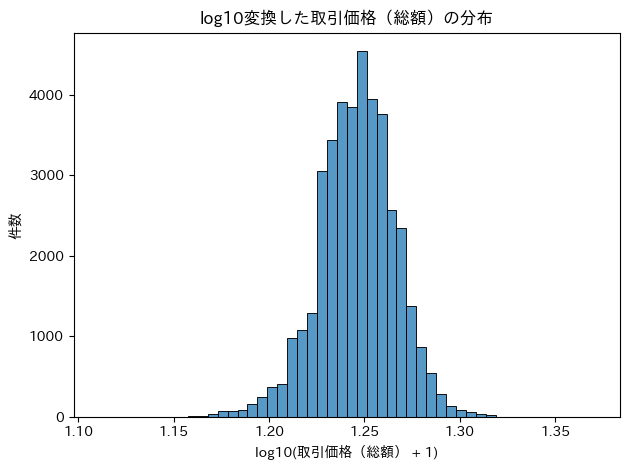

In [20]:
prices = df["取引価格（総額）"].dropna()

print(prices.describe())

sns.histplot(np.log10(prices), bins=50, kde=False)
plt.title("log10変換した取引価格（総額）の分布")

plt.xlabel("log10(取引価格（総額） + 1)")
plt.ylabel("件数")

plt.tight_layout()

#### 最寄駅：距離（分）

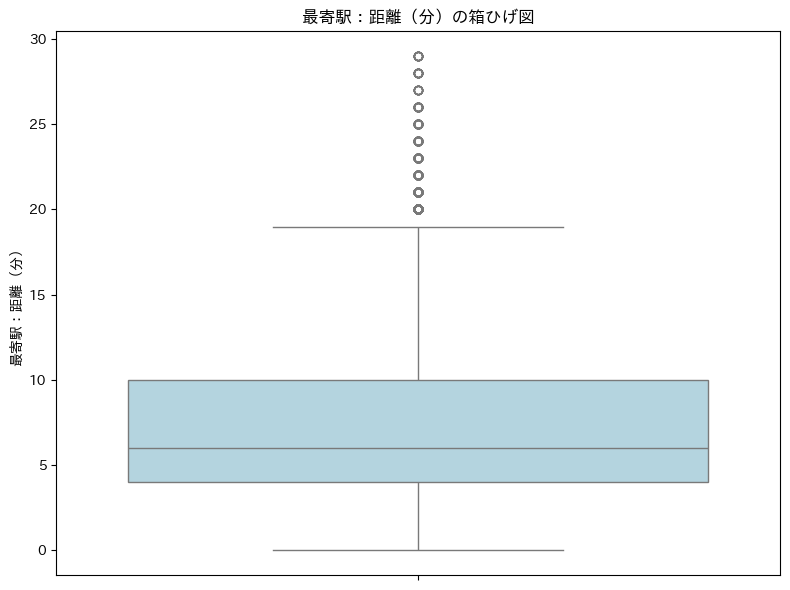

最寄駅：距離（分）が30分を超える外れ値の件数: 0


In [21]:
# 最寄駅：距離（分）を箱ひげ図で可視化
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["最寄駅：距離（分）"], color="lightblue")
plt.title("最寄駅：距離（分）の箱ひげ図")
plt.ylabel("最寄駅：距離（分）")
plt.tight_layout()
plt.show()

# 外れ値の件数を確認
outliers = df[df["最寄駅：距離（分）"] > 30]
print(f"最寄駅：距離（分）が30分を超える外れ値の件数: {len(outliers)}")

最寄駅：距離（分）:基本的には外れ値はなし

#### 面積

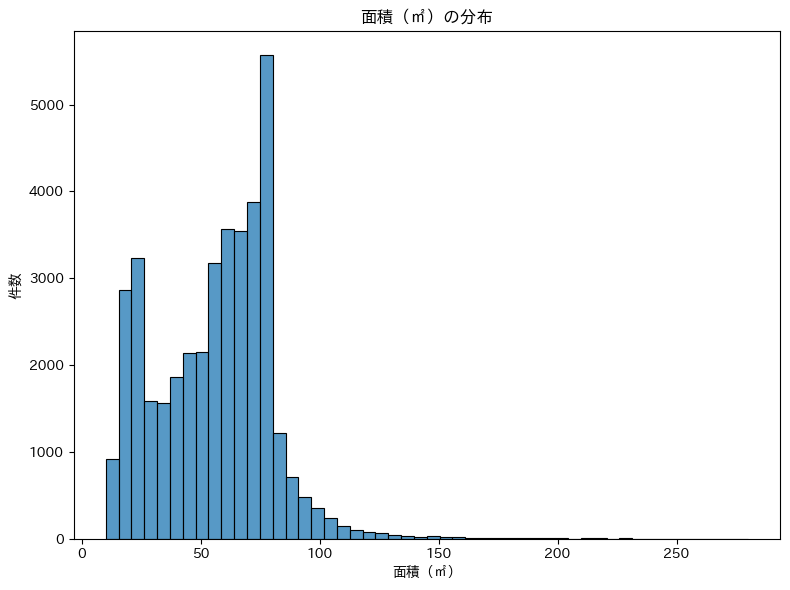

In [22]:
# 面積の分布を確認
plt.figure(figsize=(8, 6))
sns.histplot(df["面積（㎡）"].dropna(), bins=50, kde=False)
plt.title("面積（㎡）の分布")
plt.xlabel("面積（㎡）")
plt.ylabel("件数")
plt.tight_layout()
plt.show()

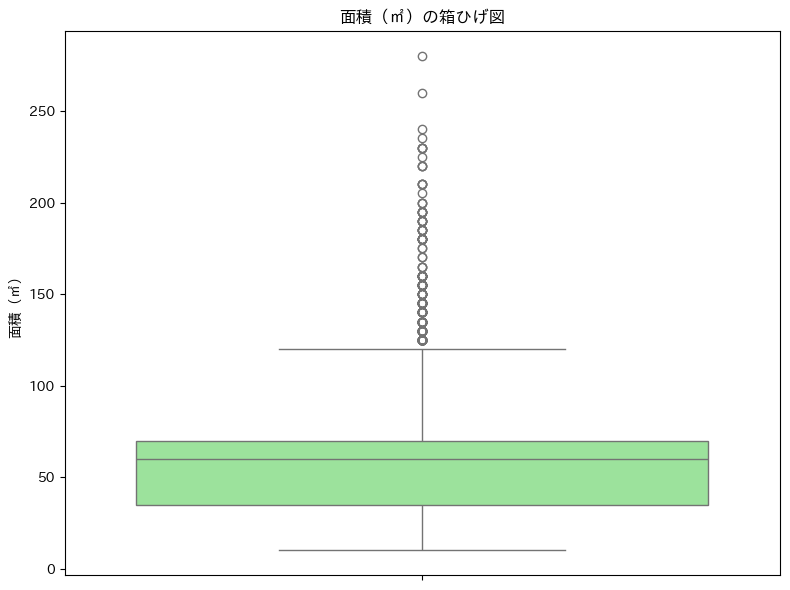

面積（㎡）が200を超える物件の件数: 0
面積（㎡）の最小値: 10
面積（㎡）の最大値: 280


In [23]:
# 箱ひげ図を可視化
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["面積（㎡）"], color="lightgreen")
plt.title("面積（㎡）の箱ひげ図")
plt.ylabel("面積（㎡）")
plt.tight_layout()
plt.show()

# 外れ値の件数
outliers = df[df["面積（㎡）"] > 300]
print(f"面積（㎡）が200を超える物件の件数: {len(outliers)}")
print(f"面積（㎡）の最小値: {df['面積（㎡）'].min()}")
print(f"面積（㎡）の最大値: {df['面積（㎡）'].max()}")

面積（㎡）: 300㎡を超える物件は削除

#### 築年数・築年数

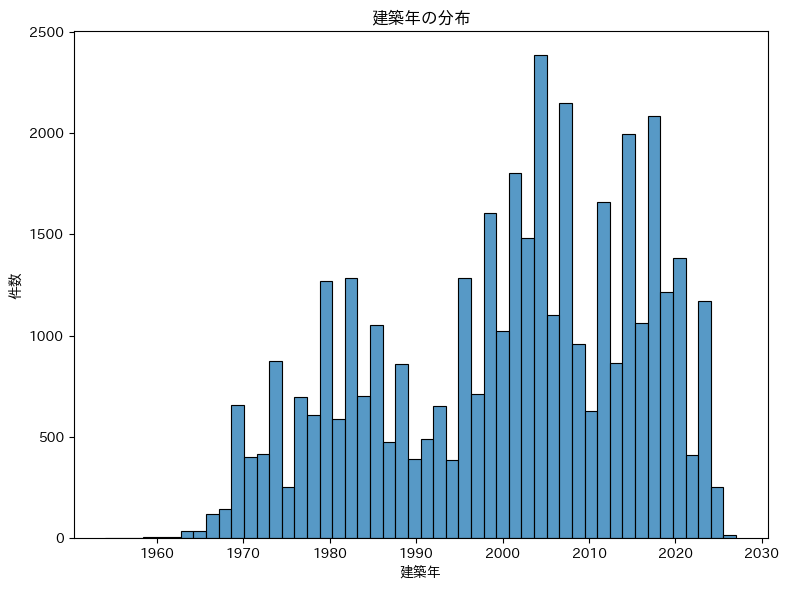

In [24]:
# 建築年の分布を確認
plt.figure(figsize=(8, 6))
sns.histplot(df["建築年"].dropna(), bins=50, kde=False)
plt.title("建築年の分布")
plt.xlabel("建築年")
plt.ylabel("件数")
plt.tight_layout()
plt.show()

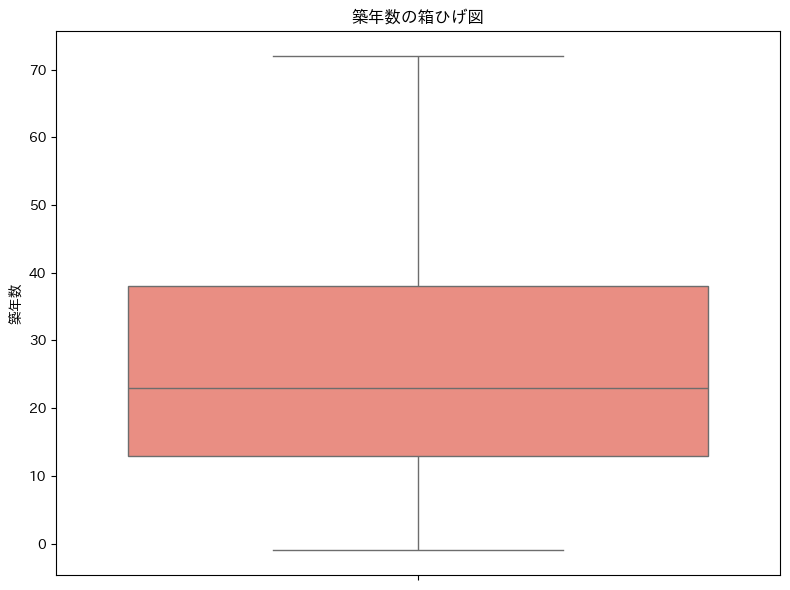

In [25]:
# 築年数の外れ値分析
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["築年数"], color="salmon")
plt.title("築年数の箱ひげ図")
plt.ylabel("築年数")
plt.tight_layout()
plt.show()

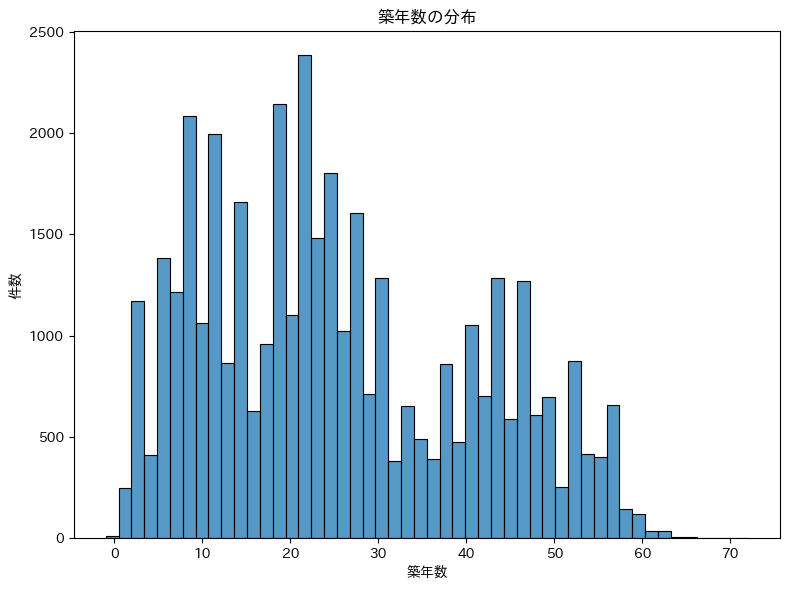

In [26]:
# 築年数の分布の確認
plt.figure(figsize=(8, 6))
sns.histplot(df["築年数"].dropna(), bins=50, kde=False)
plt.title("築年数の分布")
plt.xlabel("築年数")
plt.ylabel("件数")
plt.tight_layout()
plt.show()  # 建築年は削除かな？

#### 建物の構造、用途、今後の利用目的、都市計画

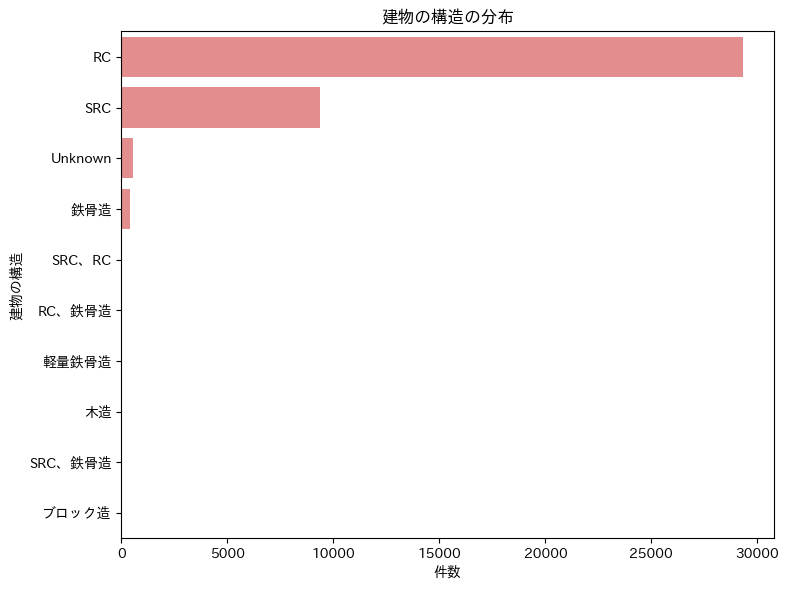

In [27]:
# 建物の構造 の分布を確認
plt.figure(figsize=(8, 6))
sns.countplot(y=df["建物の構造"], order=df["建物の構造"].value_counts().index, color="lightcoral")
plt.title("建物の構造の分布")
plt.xlabel("件数")
plt.ylabel("建物の構造")
plt.tight_layout()
plt.show()

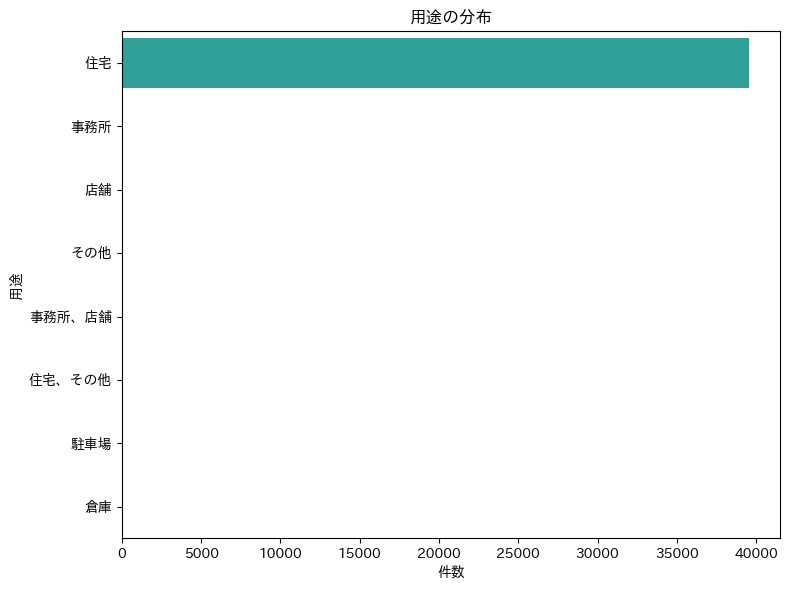

用途
住宅        39535
事務所          56
店舗           38
その他          22
事務所、店舗        3
住宅、その他        2
駐車場           2
倉庫            1
Name: count, dtype: int64


In [28]:
# 用途 の分布を確認
plt.figure(figsize=(8, 6))
sns.countplot(y=df["用途"], order=df["用途"].value_counts().index, color="lightseagreen")
plt.title("用途の分布")
plt.xlabel("件数")
plt.ylabel("用途")
plt.tight_layout()
plt.show()

print(df["用途"].value_counts())

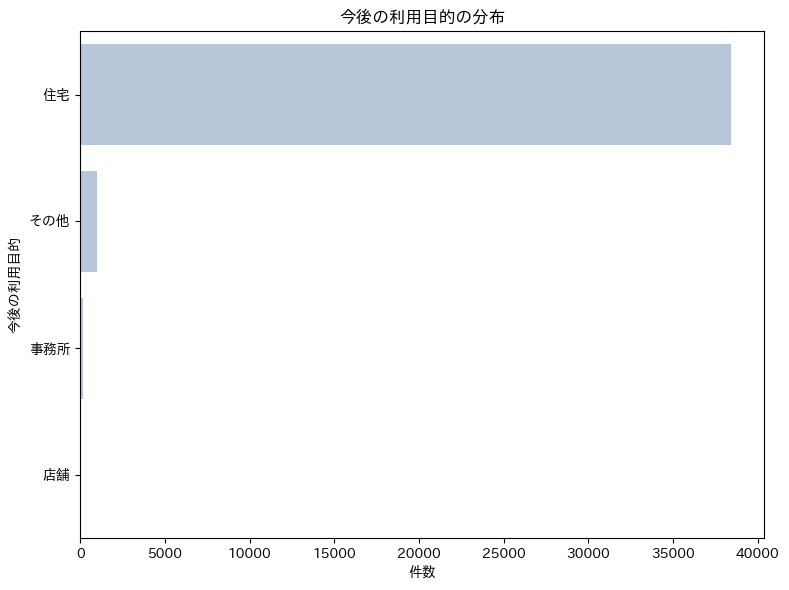

今後の利用目的
住宅     38446
その他      981
事務所      183
店舗        49
Name: count, dtype: int64


In [29]:
# 今後の利用目的 の分布を確認
plt.figure(figsize=(8, 6))
sns.countplot(y=df["今後の利用目的"], order=df["今後の利用目的"].value_counts().index, color="lightsteelblue")
plt.title("今後の利用目的の分布")
plt.xlabel("件数")
plt.ylabel("今後の利用目的")
plt.tight_layout()
plt.show()

print(df["今後の利用目的"].value_counts())

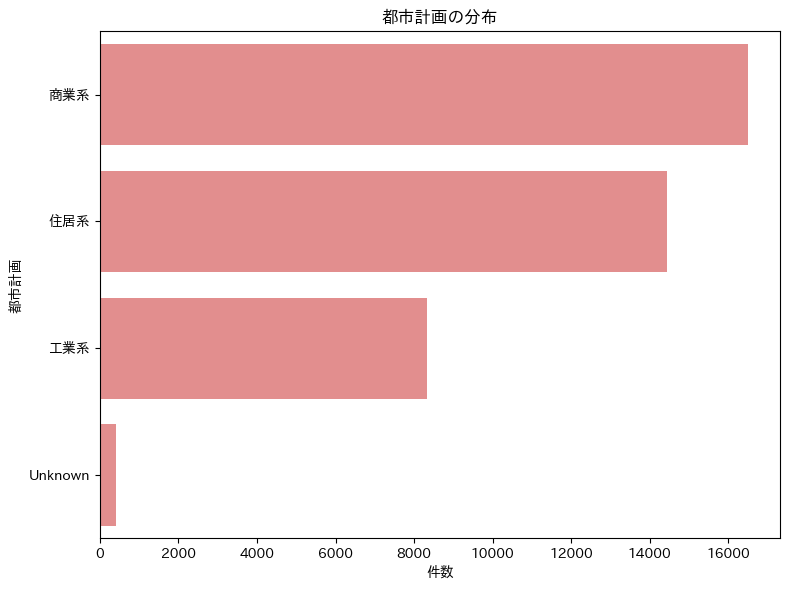

都市計画
商業系        16492
住居系        14429
工業系         8337
Unknown      401
Name: count, dtype: int64


In [30]:
# 都市計画 の分布を確認
plt.figure(figsize=(8, 6))
sns.countplot(y=df["都市計画"], order=df["都市計画"].value_counts().index, color="lightcoral")
plt.title("都市計画の分布")
plt.xlabel("件数")
plt.ylabel("都市計画")
plt.tight_layout()
plt.show()

print(df["都市計画"].value_counts())

- 方針
  - 建物の構造: そのまま
  - 用途: 一旦そのまま
  - 今後の利用目的: そのまま
  - 都市計画: カテゴリ分け


全てカテゴリ化はするが、基本的にはノータッチ

#### 建ぺい率（％）、容積率（％）

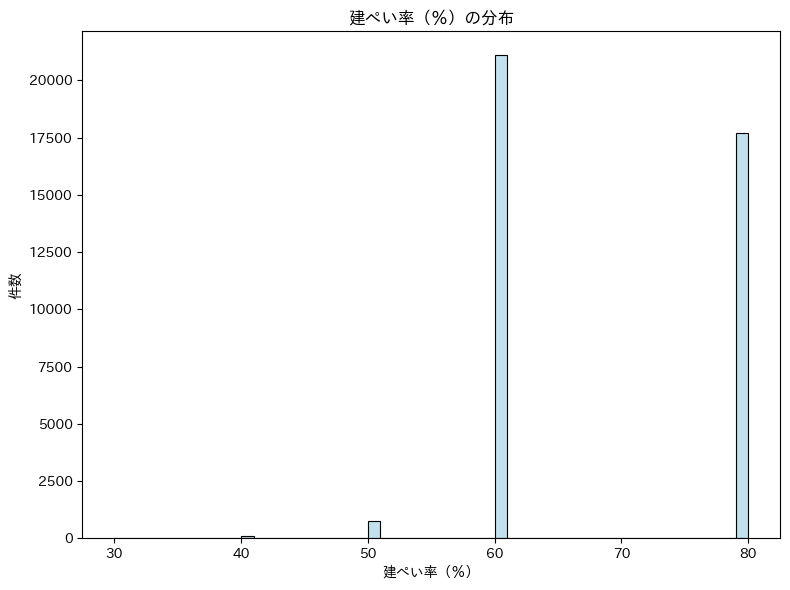

建ぺい率（％）
60.0    21090
80.0    17720
50.0      758
40.0       90
30.0        1
Name: count, dtype: int64
count    39659.000000
mean        68.698908
std         10.290627
min         30.000000
25%         60.000000
50%         60.000000
75%         80.000000
max         80.000000
Name: 建ぺい率（％）, dtype: float64


In [31]:
# 建ぺい率（％） の分布を確認
plt.figure(figsize=(8, 6))
sns.histplot(df["建ぺい率（％）"].dropna(), bins=50, kde=False, color="lightblue")
plt.title("建ぺい率（％）の分布")
plt.xlabel("建ぺい率（％）")
plt.ylabel("件数")
plt.tight_layout()
plt.show()

print(df["建ぺい率（％）"].value_counts())
print(df["建ぺい率（％）"].describe())

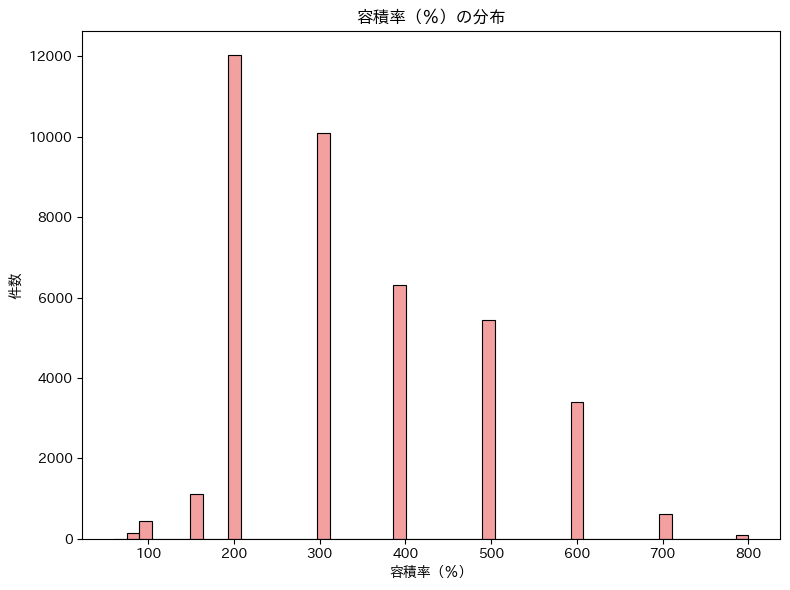

容積率（％）
200.0    12023
300.0    10102
400.0     6324
500.0     5449
600.0     3389
150.0     1100
700.0      614
100.0      430
80.0       130
800.0       97
60.0         1
Name: count, dtype: int64
count    39659.000000
mean       339.104869
std        143.494374
min         60.000000
25%        200.000000
50%        300.000000
75%        400.000000
max        800.000000
Name: 容積率（％）, dtype: float64


In [32]:
# 容積率（％） の分布を確認
plt.figure(figsize=(8, 6))
sns.histplot(df["容積率（％）"].dropna(), bins=50, kde=False, color="lightcoral")
plt.title("容積率（％）の分布")
plt.xlabel("容積率（％）")
plt.ylabel("件数")
plt.tight_layout()
plt.show()

print(df["容積率（％）"].value_counts())
print(df["容積率（％）"].describe())

- 方針
  - 建ぺい率（％）: 40.0, 30.0は除去
  - 容積率（％）: 下限(60.0), x >= 800.0は除去

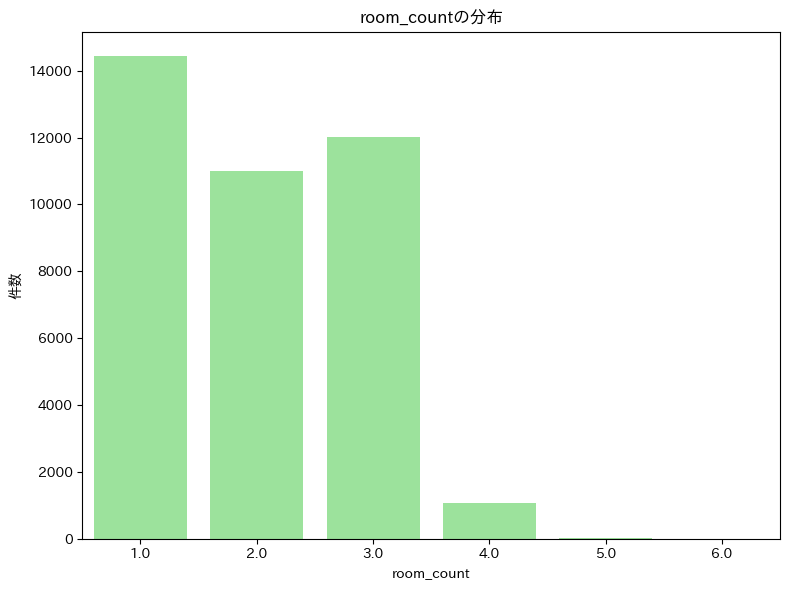

room_count
1.0    14448
3.0    12012
2.0    10995
4.0     1067
5.0       15
6.0        2
Name: count, dtype: int64
count    38539.000000
mean         1.993539
std          0.895340
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: room_count, dtype: float64


In [33]:
# room_count の分布を確認
plt.figure(figsize=(8, 6))
sns.countplot(x=df["room_count"].dropna(), color="lightgreen")
plt.title("room_countの分布")
plt.xlabel("room_count")
plt.ylabel("件数")
plt.tight_layout()
plt.show()

print(df["room_count"].value_counts())
print(df["room_count"].describe())

### 特徴量エンジニアリングのためのEDA

In [34]:
# 前処理を施したデータフレームを用意
path = '../data/raw/Tokyo_20251_20254.csv'

df = preprocess_data(path)
df = engineer_features(df)
display(df.isna().sum())
display(df.head())

種類                0
価格情報区分            0
市区町村コード           0
最寄駅：名称            0
最寄駅：距離（分）         0
取引価格（総額）          0
面積（㎡）             0
建築年               0
建物の構造             0
用途                0
今後の利用目的           0
都市計画              0
建ぺい率（％）           0
容積率（％）            0
改装            27857
築年数               0
最寄駅：緯度          871
最寄駅：経度          871
住所                0
room_count     1120
has_L             0
has_D             0
has_K             0
has_S             0
取引四半期             0
dtype: int64

,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引四半期
0,中古マンション等,1,13101,小伝馬町,2.0,17.893048,45,2014.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,12.0,35.690737,139.778433,東京都千代田区岩本町,1.0,1,1,1,0,1
1,中古マンション等,1,13101,岩本町,4.0,18.603002,55,2023.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,3.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,1
2,中古マンション等,1,13101,岩本町,5.0,17.453097,40,2007.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,19.0,35.695534,139.775866,東京都千代田区岩本町,1.0,0,1,1,0,1
3,中古マンション等,1,13101,岩本町,3.0,17.989898,45,2016.0,RC,住宅,住宅,Unknown,80.0,600.0,NaN,10.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,1
4,中古マンション等,1,13101,市ケ谷,3.0,17.622173,35,2005.0,鉄骨造,住宅,住宅,商業系,80.0,700.0,NaN,21.0,35.691000,139.735583,東京都千代田区九段北,1.0,0,0,1,0,1


In [35]:
target = df["取引価格（総額）"]

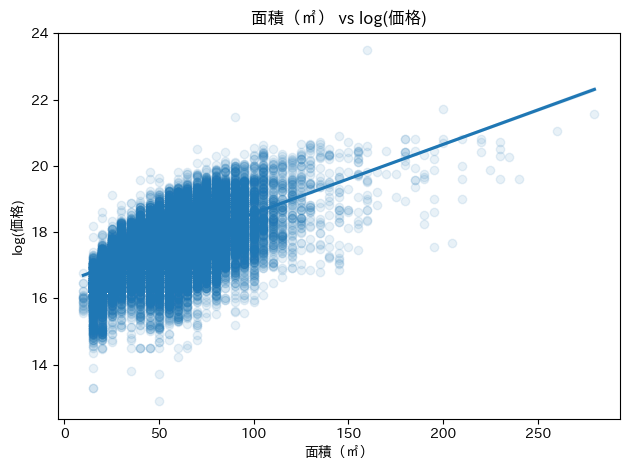

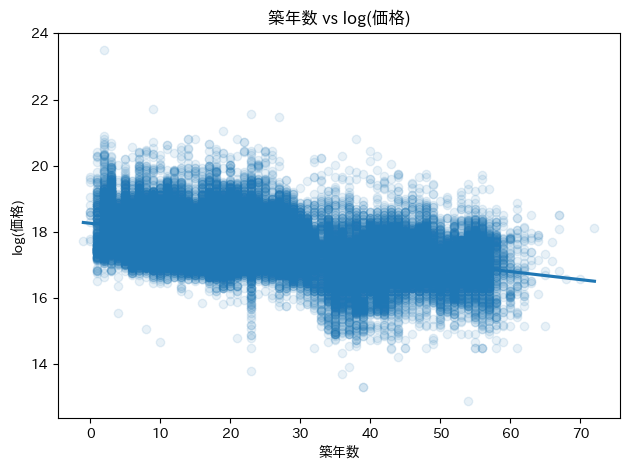

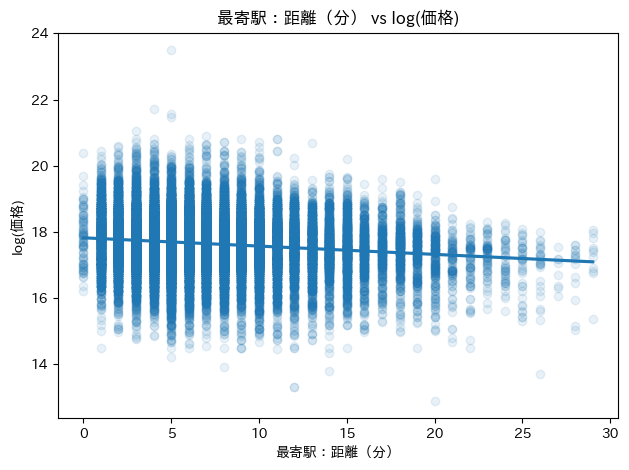

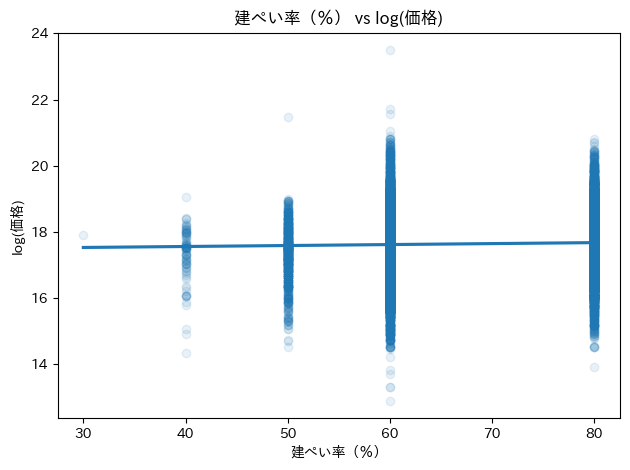

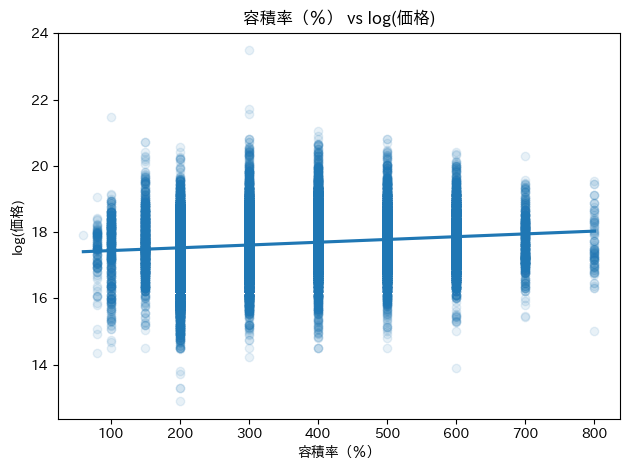

In [ ]:
# 数値特徴量との散布図 + 回帰直線
for col in ["面積（㎡）", "築年数", "最寄駅：距離（分）", "建ぺい率（％）", "容積率（％）"]:
    sns.regplot(x=df[col], y=target, scatter_kws={"alpha": 0.1})
    plt.title(f"{col} vs log(価格)")
    plt.xlabel(col)
    plt.ylabel("log(価格)")
    plt.tight_layout()
    plt.show()

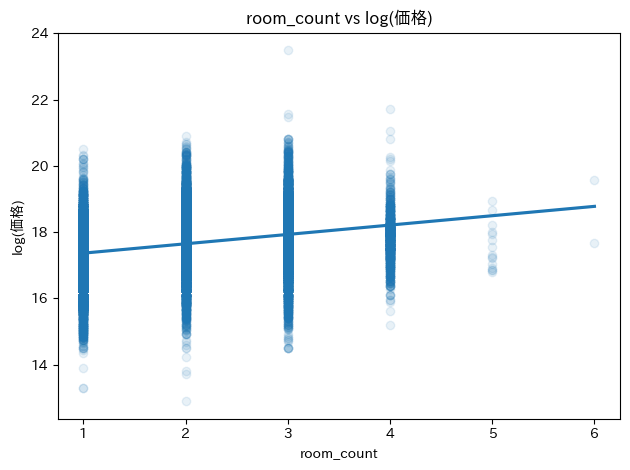

In [37]:
# room_countと価格の関係を散布図で確認
sns.regplot(x=df["room_count"], y=target, scatter_kws={"alpha": 0.1})
plt.title("room_count vs log(価格)")
plt.xlabel("room_count")
plt.ylabel("log(価格)")
plt.tight_layout()
plt.show()

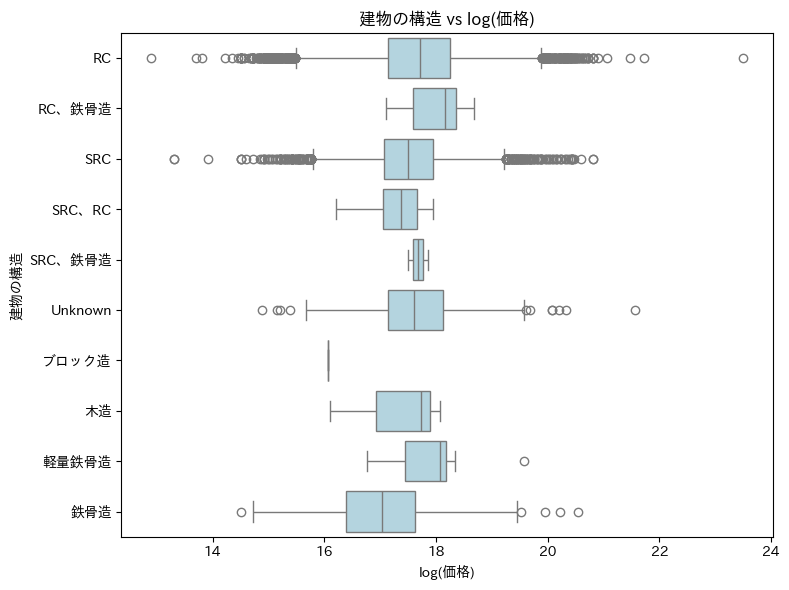

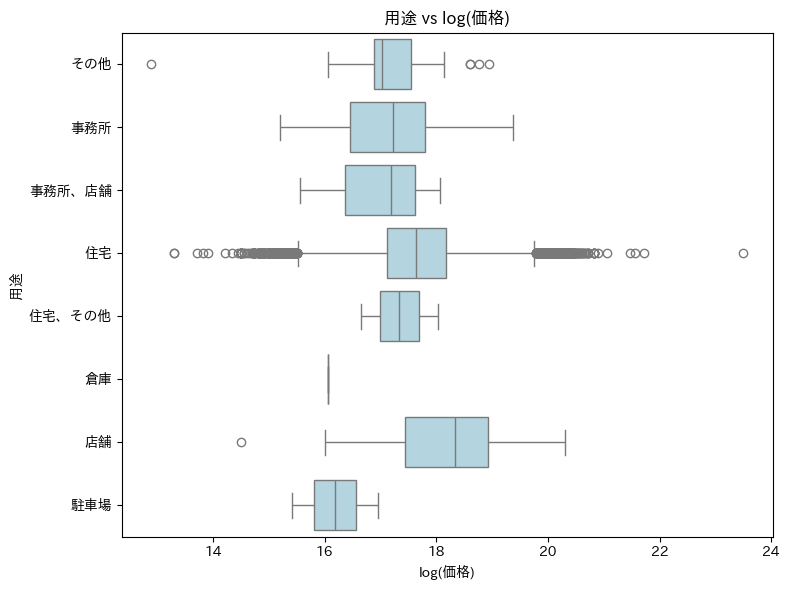

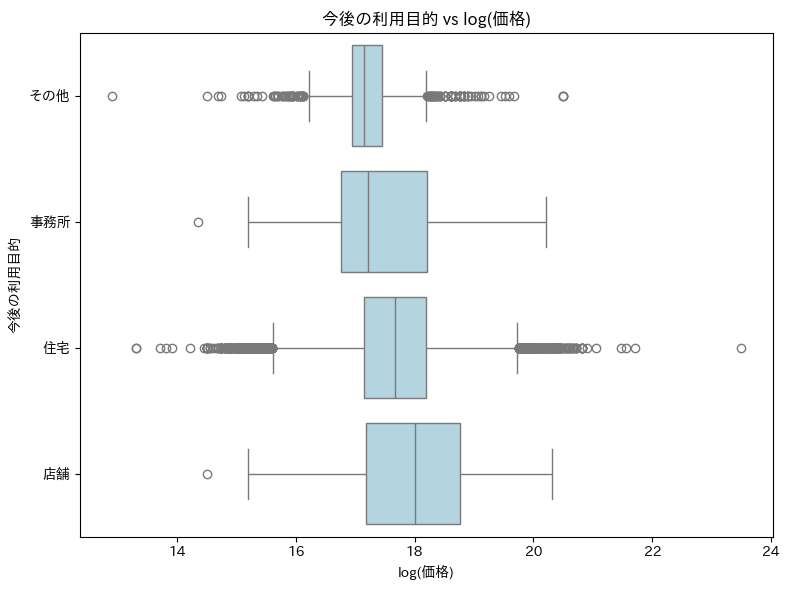

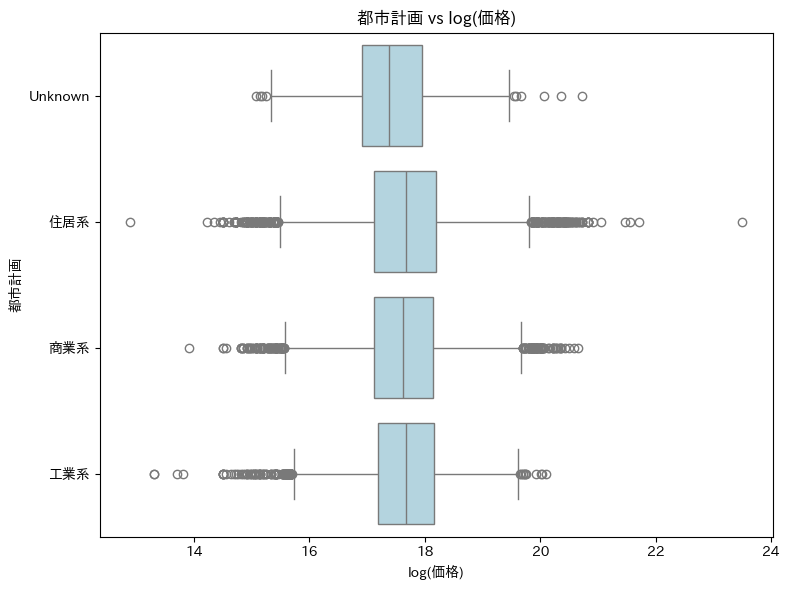

In [38]:
# カテゴリ特徴量と箱ひげ図
for col in ["建物の構造", "用途", "今後の利用目的", "都市計画"]:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col], x=target, color="lightblue")
    plt.title(f"{col} vs log(価格)")
    plt.xlabel("log(価格)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

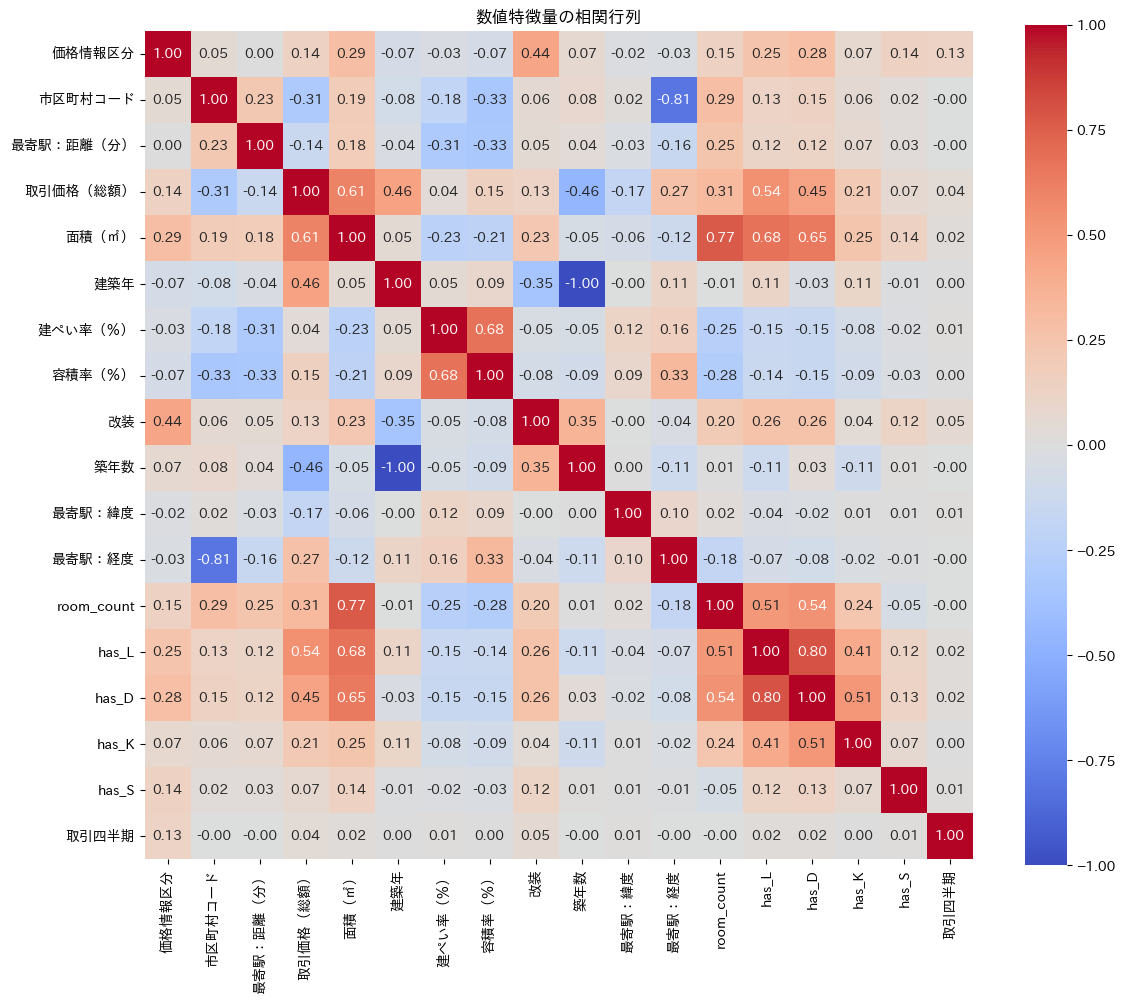

相関係数を確認(数値列のみ):
取引価格（総額）      1.000000
面積（㎡）         0.607345
has_L         0.539726
建築年           0.457053
has_D         0.452974
room_count    0.314116
最寄駅：経度        0.268228
has_K         0.211404
容積率（％）        0.149304
価格情報区分        0.139578
改装            0.130740
has_S         0.069577
取引四半期         0.041135
建ぺい率（％）       0.037219
最寄駅：距離（分）    -0.135320
最寄駅：緯度       -0.173167
市区町村コード      -0.308224
築年数          -0.457053
Name: 取引価格（総額）, dtype: float64


In [41]:
# 相関係数を確認(数値列のみ)
num_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("数値特徴量の相関行列")
plt.tight_layout()
plt.show()

print(f"相関係数を確認(数値列のみ):\n{correlation_matrix['取引価格（総額）'].sort_values(ascending=False)}")